# Mentoría PDIS — Notebook 03
# Aprendizaje Supervisado
## SVM + Random Forest + Perceptrón Multicapa
### GridSearch + Validación Cruzada Agrupada + Transferencia de Dominio

Este notebook continúa desde los tres Data Marts generados en el Notebook 01.

## Objetivo

Comparar tres familias de modelos supervisados:

- **SVM**
- **Random Forest**
- **MLPClassifier** (Perceptrón Multicapa)

con una metodología rigurosa que preserve la independencia espacial.

---

# Regla crítica

La unidad indivisible de validación es:

```text
polygon_id
```

Todos los píxeles de un mismo polígono deben permanecer en el mismo fold.

Nunca se usa un split aleatorio puro por píxel.

---

# Validación global

Se usa:

```python
StratifiedGroupKFold(n_splits=10)
```

para realizar **10-fold cross-validation** durante GridSearchCV.

---

# Transferencia de dominio

Después del benchmark global se evalúan dos experimentos:

```text
Train: Olaroz
Test : Hombre Muerto
```

```text
Train: Hombre Muerto
Test : Olaroz
```

El dominio destino nunca participa en la selección de hiperparámetros.

---

# Métrica principal

```text
F1-macro
```

Además:

- Balanced Accuracy
- Accuracy
- Precision macro
- Recall macro
- métricas por clase
- matriz de confusión
- importancia de features
- tiempo de entrenamiento

## 0. Dependencias

```bash
pip install pandas numpy matplotlib scikit-learn pyarrow
```

El notebook incluye un modo **Low-RAM** pensado para notebooks de 12 GB de RAM.

In [1]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 150)

# 1. Configuración

In [2]:
DATA_DIR = Path("outputs_datamarts")

DM1_PATH = DATA_DIR / "data_mart_01_fisico_completo.parquet"
DM2_PATH = DATA_DIR / "data_mart_02_indices_compacto.parquet"
DM3_PATH = DATA_DIR / "data_mart_03_contexto_espacial.parquet"
METADATA_PATH = DATA_DIR / "metadata_datamarts.json"

OUTPUT_DIR = Path("outputs_supervised")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "sample_id"
GROUP_COL = "polygon_id"
DOMAIN_COL = "salar"
TARGET_COL = "clase"

# GridSearch global: 10-fold CV preservando polygon_id.
GLOBAL_CV_FOLDS = 10

# Transferencia dentro de un único salar: 5 folds es más estable,
# ya que cada salar tiene 6 polígonos por clase.
TRANSFER_CV_FOLDS = 5

# Evitar saturar una notebook modesta.
N_JOBS = 2

# ------------------------------------------------------------
# LOW RAM
# ------------------------------------------------------------
LOW_RAM_MODE = True
MAX_SAMPLES_PER_POLYGON = 1000
N_SAMPLE_BINS = 5
SAMPLE_RANDOM_STATE = 42

# ------------------------------------------------------------
# Permutation Importance
# ------------------------------------------------------------
PERMUTATION_SAMPLE_SIZE = 2500
PERMUTATION_REPEATS = 5

# 2. Hiperparámetros

In [3]:
SVM_GRID = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.5, 1.0, 5.0],
    "model__gamma": ["scale"],
}

RF_GRID = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"],
}

MLP_GRID = {
    "model__hidden_layer_sizes": [(64,), (128, 64)],
    "model__alpha": [1e-4, 1e-3],
    "model__learning_rate_init": [1e-3],
}

Los grids son deliberadamente compactos.

Con 3 Data Marts × 3 modelos × 10 folds, un grid enorme puede generar cientos o miles de entrenamientos sin necesariamente aportar valor.

Primero buscamos una región razonable del espacio de hiperparámetros. Luego, si un modelo destaca, se puede hacer una búsqueda fina específica.

# 3. Carga de Data Marts

In [4]:
def load_parquet_or_csv(parquet_path: Path) -> pd.DataFrame:
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)

    csv_path = parquet_path.with_suffix(".csv")

    if csv_path.exists():
        return pd.read_csv(csv_path)

    raise FileNotFoundError(
        f"No se encontró {parquet_path} ni {csv_path}"
    )


data_mart_01 = load_parquet_or_csv(DM1_PATH)
data_mart_02 = load_parquet_or_csv(DM2_PATH)
data_mart_03 = load_parquet_or_csv(DM3_PATH)

print("DM1:", data_mart_01.shape)
print("DM2:", data_mart_02.shape)
print("DM3:", data_mart_03.shape)

DM1: (38621, 41)
DM2: (38621, 31)
DM3: (38621, 47)


In [5]:
with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

print("Data Marts:")
print(list(metadata["data_marts"].keys()))

Data Marts:
['DM1_fisico_completo', 'DM2_indices_compacto', 'DM3_contexto_espacial']


# 4. Features oficiales de cada Data Mart

In [6]:
data_mart_specs = {
    "DM1_fisico_completo": {
        "data": data_mart_01,
        "features": metadata["data_marts"]["DM1_fisico_completo"]["features"],
    },
    "DM2_indices_compacto": {
        "data": data_mart_02,
        "features": metadata["data_marts"]["DM2_indices_compacto"]["features"],
    },
    "DM3_contexto_espacial": {
        "data": data_mart_03,
        "features": metadata["data_marts"]["DM3_contexto_espacial"]["features"],
    },
}

for mart_name, spec in data_mart_specs.items():
    missing = [
        feature
        for feature in spec["features"]
        if feature not in spec["data"].columns
    ]

    if missing:
        raise ValueError(f"{mart_name}: faltan features {missing}")

    print(mart_name, "->", len(spec["features"]), "features")

DM1_fisico_completo -> 27 features
DM2_indices_compacto -> 17 features
DM3_contexto_espacial -> 33 features


# 5. Sample inteligente opcional

Para una máquina de 12 GB de RAM conviene limitar la cantidad de píxeles por polígono.

No se usa `df.sample()` global.

El muestreo se hace dentro de cada `polygon_id`, intentando cubrir distintos cuantiles de diversidad espectral. Después se reutilizan exactamente los mismos `sample_id` en los tres Data Marts.

In [7]:
DIVERSITY_FEATURE_CANDIDATES = [
    "eng_brightness",
    "eng_visible_mean",
    "feat_BSI",
    "feat_NDVI",
    "spec_B04",
]


def choose_diversity_feature(data: pd.DataFrame) -> str | None:
    for feature in DIVERSITY_FEATURE_CANDIDATES:
        if feature in data.columns:
            return feature
    return None


def sample_one_polygon(
    polygon_df: pd.DataFrame,
    max_samples: int,
    diversity_feature: str | None,
    n_bins: int,
    random_state: int,
) -> pd.DataFrame:

    if len(polygon_df) <= max_samples:
        return polygon_df.copy()

    if diversity_feature is None:
        return polygon_df.sample(
            n=max_samples,
            random_state=random_state,
        ).copy()

    work = polygon_df.copy()

    try:
        work["_sample_bin"] = pd.qcut(
            work[diversity_feature],
            q=n_bins,
            labels=False,
            duplicates="drop",
        )
    except ValueError:
        return work.sample(
            n=max_samples,
            random_state=random_state,
        ).copy()

    bins = sorted(work["_sample_bin"].dropna().unique().tolist())

    if not bins:
        return work.sample(
            n=max_samples,
            random_state=random_state,
        ).copy()

    quota = max(1, max_samples // len(bins))
    parts = []

    for bin_id in bins:
        bin_df = work[work["_sample_bin"] == bin_id]
        n_take = min(len(bin_df), quota)

        parts.append(
            bin_df.sample(
                n=n_take,
                random_state=random_state + int(bin_id) + 1,
            )
        )

    selected = pd.concat(parts, axis=0)
    missing = max_samples - len(selected)

    if missing > 0:
        remaining = work.loc[~work.index.isin(selected.index)]

        if len(remaining) > 0:
            extra = remaining.sample(
                n=min(missing, len(remaining)),
                random_state=random_state + 1000,
            )
            selected = pd.concat([selected, extra], axis=0)

    return selected.drop(
        columns=["_sample_bin"],
        errors="ignore",
    ).copy()


def intelligent_sample(
    data: pd.DataFrame,
    max_samples_per_polygon: int,
    n_bins: int,
    random_state: int,
) -> pd.DataFrame:

    diversity_feature = choose_diversity_feature(data)
    print("Feature de diversidad:", diversity_feature)

    parts = []

    for i, (_, polygon_df) in enumerate(
        data.groupby(GROUP_COL, sort=True)
    ):
        parts.append(
            sample_one_polygon(
                polygon_df=polygon_df,
                max_samples=max_samples_per_polygon,
                diversity_feature=diversity_feature,
                n_bins=n_bins,
                random_state=random_state + i,
            )
        )

    return pd.concat(parts, axis=0).reset_index(drop=True)

In [8]:
if LOW_RAM_MODE:
    original_n = len(data_mart_01)

    data_mart_01 = intelligent_sample(
        data=data_mart_01,
        max_samples_per_polygon=MAX_SAMPLES_PER_POLYGON,
        n_bins=N_SAMPLE_BINS,
        random_state=SAMPLE_RANDOM_STATE,
    )

    selected_ids = set(
        data_mart_01[ID_COL].astype(str).tolist()
    )

    data_mart_02 = (
        data_mart_02[
            data_mart_02[ID_COL].astype(str).isin(selected_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )

    data_mart_03 = (
        data_mart_03[
            data_mart_03[ID_COL].astype(str).isin(selected_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )

    data_mart_specs["DM1_fisico_completo"]["data"] = data_mart_01
    data_mart_specs["DM2_indices_compacto"]["data"] = data_mart_02
    data_mart_specs["DM3_contexto_espacial"]["data"] = data_mart_03

    print("Muestras originales:", original_n)
    print("Muestras Low-RAM   :", len(data_mart_01))

Feature de diversidad: eng_brightness
Muestras originales: 38621
Muestras Low-RAM   : 38621


# 6. Auditoría del sample

In [9]:
sample_audit = (
    data_mart_01
    .groupby([DOMAIN_COL, TARGET_COL, GROUP_COL])
    .size()
    .rename("n_samples")
    .reset_index()
)

display(sample_audit)

print("Polígonos:", data_mart_01[GROUP_COL].nunique())
print("Clases   :", sorted(data_mart_01[TARGET_COL].unique()))
print("Dominios :", sorted(data_mart_01[DOMAIN_COL].unique()))

,salar,clase,polygon_id,n_samples
0,hombre_muerto,agua_humedad,HOM_AGU_001,768
1,hombre_muerto,agua_humedad,HOM_AGU_002,769
2,hombre_muerto,agua_humedad,HOM_AGU_003,252
3,hombre_muerto,agua_humedad,HOM_AGU_004,503
4,hombre_muerto,agua_humedad,HOM_AGU_005,267
5,hombre_muerto,agua_humedad,HOM_AGU_006,625
6,hombre_muerto,salina,HOM_SAL_001,236
7,hombre_muerto,salina,HOM_SAL_002,736
8,hombre_muerto,salina,HOM_SAL_003,108
9,hombre_muerto,salina,HOM_SAL_004,417


Polígonos: 48
Clases   : ['agua_humedad', 'salina', 'suelo_desnudo', 'suelo_rocoso']
Dominios : ['hombre_muerto', 'olaroz']


# 7. Pipelines de modelos

In [10]:
def build_models() -> dict:
    svm = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                SVC(
                    class_weight="balanced",
                    cache_size=2000,
                ),
            ),
        ]
    )

    rf = Pipeline(
        steps=[
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    class_weight="balanced_subsample",
                    n_jobs=1,
                ),
            ),
        ]
    )

    mlp = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                MLPClassifier(
                    max_iter=500,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=20,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    return {
        "SVM": {
            "estimator": svm,
            "param_grid": SVM_GRID,
        },
        "RandomForest": {
            "estimator": rf,
            "param_grid": RF_GRID,
        },
        "MLP": {
            "estimator": mlp,
            "param_grid": MLP_GRID,
        },
    }

# 8. Métricas y scoring

In [11]:
SCORING = {
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}


def classification_metrics(y_true, y_pred) -> dict:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "f1_macro": float(
            f1_score(y_true, y_pred, average="macro")
        ),
        "precision_macro": float(
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "recall_macro": float(
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
    }

# 9. GridSearch global — 10-fold StratifiedGroupKFold

In [12]:
def run_global_grid_search(
    data: pd.DataFrame,
    feature_columns: list[str],
    mart_name: str,
    model_name: str,
    estimator,
    param_grid: dict,
):

    X = data[feature_columns]
    y = data[TARGET_COL].astype(str)
    groups = data[GROUP_COL].astype(str)

    cv = StratifiedGroupKFold(
        n_splits=GLOBAL_CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=SCORING,
        refit="f1_macro",
        cv=cv,
        n_jobs=N_JOBS,
        return_train_score=False,
        verbose=1,
    )

    start = perf_counter()

    grid.fit(
        X,
        y,
        groups=groups,
    )

    elapsed = perf_counter() - start

    return {
        "data_mart": mart_name,
        "model": model_name,
        "best_cv_f1_macro": float(grid.best_score_),
        "fit_seconds": float(elapsed),
        "best_params": grid.best_params_,
        "best_estimator": grid.best_estimator_,
        "cv_results": pd.DataFrame(grid.cv_results_),
    }

# 10. Ejecutar benchmark global

In [13]:
models = build_models()

global_results = []
best_estimators = {}
cv_detail_frames = []

for mart_name, spec in data_mart_specs.items():
    data = spec["data"]
    features = spec["features"]

    print("\n" + "=" * 80)
    print(mart_name)
    print("=" * 80)

    for model_name, model_spec in models.items():
        print(f"\n{model_name}")

        result = run_global_grid_search(
            data=data,
            feature_columns=features,
            mart_name=mart_name,
            model_name=model_name,
            estimator=model_spec["estimator"],
            param_grid=model_spec["param_grid"],
        )

        global_results.append(
            {
                "data_mart": mart_name,
                "model": model_name,
                "best_cv_f1_macro": result["best_cv_f1_macro"],
                "fit_seconds": result["fit_seconds"],
                "best_params": json.dumps(
                    result["best_params"],
                    ensure_ascii=False,
                ),
            }
        )

        best_estimators[(mart_name, model_name)] = result[
            "best_estimator"
        ]

        detail = result["cv_results"].copy()
        detail["data_mart"] = mart_name
        detail["model"] = model_name
        cv_detail_frames.append(detail)


global_results_df = pd.DataFrame(global_results)

display(
    global_results_df.sort_values(
        "best_cv_f1_macro",
        ascending=False,
    )
)


DM1_fisico_completo

SVM
Fitting 10 folds for each of 6 candidates, totalling 60 fits

RandomForest
Fitting 10 folds for each of 8 candidates, totalling 80 fits

MLP
Fitting 10 folds for each of 4 candidates, totalling 40 fits

DM2_indices_compacto

SVM
Fitting 10 folds for each of 6 candidates, totalling 60 fits

RandomForest
Fitting 10 folds for each of 8 candidates, totalling 80 fits

MLP
Fitting 10 folds for each of 4 candidates, totalling 40 fits

DM3_contexto_espacial

SVM
Fitting 10 folds for each of 6 candidates, totalling 60 fits

RandomForest
Fitting 10 folds for each of 8 candidates, totalling 80 fits

MLP
Fitting 10 folds for each of 4 candidates, totalling 40 fits


,data_mart,model,best_cv_f1_macro,fit_seconds,best_params
0,DM1_fisico_completo,SVM,0.956856,131.098286,"{""model__C"": 1.0, ""model__gamma"": ""scale"", ""mo..."
3,DM2_indices_compacto,SVM,0.955946,118.477767,"{""model__C"": 5.0, ""model__gamma"": ""scale"", ""mo..."
2,DM1_fisico_completo,MLP,0.931901,166.450456,"{""model__alpha"": 0.001, ""model__hidden_layer_s..."
5,DM2_indices_compacto,MLP,0.929376,194.657175,"{""model__alpha"": 0.001, ""model__hidden_layer_s..."
6,DM3_contexto_espacial,SVM,0.925118,60.564572,"{""model__C"": 1.0, ""model__gamma"": ""scale"", ""mo..."
1,DM1_fisico_completo,RandomForest,0.922575,1359.239452,"{""model__max_depth"": 20, ""model__max_features""..."
4,DM2_indices_compacto,RandomForest,0.917769,1151.298516,"{""model__max_depth"": 20, ""model__max_features""..."
7,DM3_contexto_espacial,RandomForest,0.915328,1316.317346,"{""model__max_depth"": 20, ""model__max_features""..."
8,DM3_contexto_espacial,MLP,0.910524,103.304062,"{""model__alpha"": 0.001, ""model__hidden_layer_s..."


# 11. Visualizar benchmark global

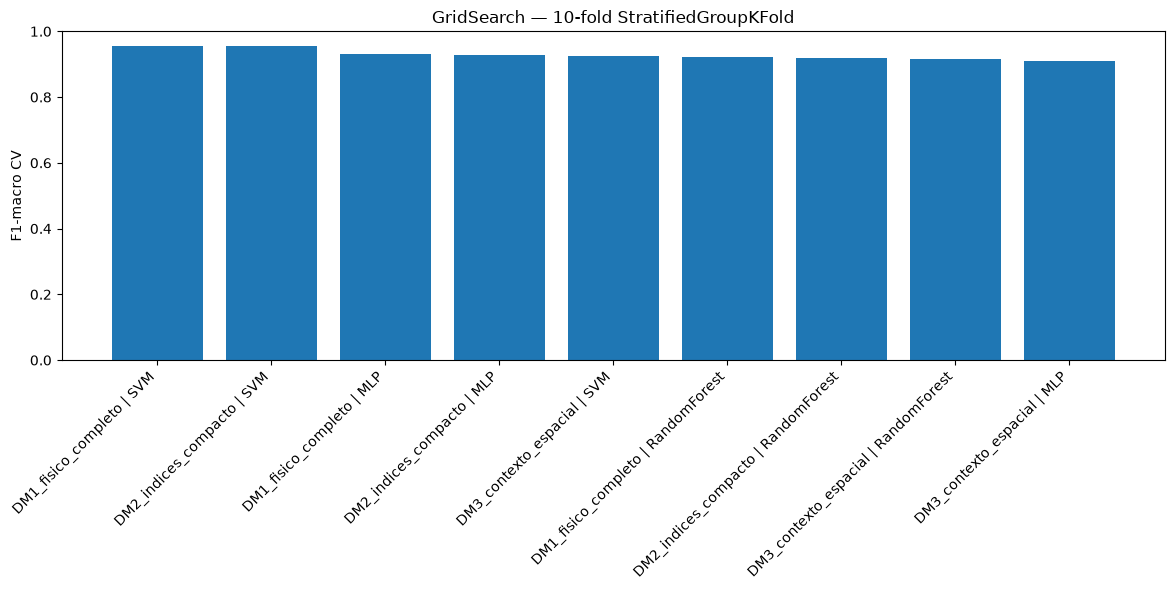

In [14]:
plot_df = (
    global_results_df
    .sort_values("best_cv_f1_macro", ascending=False)
    .copy()
)

labels = plot_df["data_mart"] + " | " + plot_df["model"]

plt.figure(figsize=(12, 6))
plt.bar(labels, plot_df["best_cv_f1_macro"])
plt.ylabel("F1-macro CV")
plt.title("GridSearch — 10-fold StratifiedGroupKFold")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 12. Transferencia de dominio

Para cada dirección:

1. se toma únicamente el dominio fuente;
2. GridSearch se hace únicamente dentro del fuente;
3. `polygon_id` sigue siendo el grupo de CV;
4. se ajusta el mejor modelo usando todo el fuente;
5. se evalúa una única vez sobre el dominio destino.

In [15]:
def run_domain_transfer(
    data: pd.DataFrame,
    feature_columns: list[str],
    mart_name: str,
    model_name: str,
    estimator,
    param_grid: dict,
    source_domain: str,
    target_domain: str,
):

    source = data[data[DOMAIN_COL] == source_domain].copy()
    target = data[data[DOMAIN_COL] == target_domain].copy()

    X_source = source[feature_columns]
    y_source = source[TARGET_COL].astype(str)
    groups_source = source[GROUP_COL].astype(str)

    X_target = target[feature_columns]
    y_target = target[TARGET_COL].astype(str)

    cv = StratifiedGroupKFold(
        n_splits=TRANSFER_CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    grid = GridSearchCV(
        estimator=clone(estimator),
        param_grid=param_grid,
        scoring=SCORING,
        refit="f1_macro",
        cv=cv,
        n_jobs=N_JOBS,
        verbose=0,
    )

    start = perf_counter()

    grid.fit(
        X_source,
        y_source,
        groups=groups_source,
    )

    y_pred = grid.best_estimator_.predict(X_target)
    elapsed = perf_counter() - start

    metrics = classification_metrics(
        y_target,
        y_pred,
    )

    report = classification_report(
        y_target,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    classes = sorted(data[TARGET_COL].astype(str).unique())

    cm = confusion_matrix(
        y_target,
        y_pred,
        labels=classes,
    )

    predictions = target[
        [ID_COL, GROUP_COL, DOMAIN_COL, TARGET_COL]
    ].copy()

    predictions["prediction"] = y_pred
    predictions["source_domain"] = source_domain

    return {
        "source_cv_f1_macro": float(grid.best_score_),
        "fit_seconds": float(elapsed),
        "best_params": grid.best_params_,
        "best_estimator": grid.best_estimator_,
        "metrics": metrics,
        "classification_report": report,
        "confusion_matrix": cm,
        "predictions": predictions,
    }

# 13. Ejecutar transferencia en ambas direcciones

In [16]:
domain_values = sorted(data_mart_01[DOMAIN_COL].unique())

if len(domain_values) != 2:
    raise ValueError("Se esperaban exactamente dos dominios.")

DOMAIN_A, DOMAIN_B = domain_values

transfer_directions = [
    (DOMAIN_A, DOMAIN_B),
    (DOMAIN_B, DOMAIN_A),
]

transfer_rows = []
transfer_objects = {}

for mart_name, spec in data_mart_specs.items():
    data = spec["data"]
    features = spec["features"]

    for model_name, model_spec in models.items():
        for source_domain, target_domain in transfer_directions:

            print(
                f"{mart_name} | {model_name} | "
                f"{source_domain} -> {target_domain}"
            )

            result = run_domain_transfer(
                data=data,
                feature_columns=features,
                mart_name=mart_name,
                model_name=model_name,
                estimator=model_spec["estimator"],
                param_grid=model_spec["param_grid"],
                source_domain=source_domain,
                target_domain=target_domain,
            )

            key = (
                mart_name,
                model_name,
                source_domain,
                target_domain,
            )

            transfer_objects[key] = result

            transfer_rows.append(
                {
                    "data_mart": mart_name,
                    "model": model_name,
                    "source_domain": source_domain,
                    "target_domain": target_domain,
                    "source_cv_f1_macro": result["source_cv_f1_macro"],
                    **result["metrics"],
                    "fit_seconds": result["fit_seconds"],
                    "best_params": json.dumps(
                        result["best_params"],
                        ensure_ascii=False,
                    ),
                }
            )

transfer_results_df = pd.DataFrame(transfer_rows)

display(
    transfer_results_df.sort_values(
        "f1_macro",
        ascending=False,
    )
)

DM1_fisico_completo | SVM | hombre_muerto -> olaroz
DM1_fisico_completo | SVM | olaroz -> hombre_muerto
DM1_fisico_completo | RandomForest | hombre_muerto -> olaroz
DM1_fisico_completo | RandomForest | olaroz -> hombre_muerto
DM1_fisico_completo | MLP | hombre_muerto -> olaroz
DM1_fisico_completo | MLP | olaroz -> hombre_muerto
DM2_indices_compacto | SVM | hombre_muerto -> olaroz
DM2_indices_compacto | SVM | olaroz -> hombre_muerto
DM2_indices_compacto | RandomForest | hombre_muerto -> olaroz
DM2_indices_compacto | RandomForest | olaroz -> hombre_muerto
DM2_indices_compacto | MLP | hombre_muerto -> olaroz
DM2_indices_compacto | MLP | olaroz -> hombre_muerto
DM3_contexto_espacial | SVM | hombre_muerto -> olaroz
DM3_contexto_espacial | SVM | olaroz -> hombre_muerto
DM3_contexto_espacial | RandomForest | hombre_muerto -> olaroz
DM3_contexto_espacial | RandomForest | olaroz -> hombre_muerto
DM3_contexto_espacial | MLP | hombre_muerto -> olaroz
DM3_contexto_espacial | MLP | olaroz -> hombre

,data_mart,model,source_domain,target_domain,source_cv_f1_macro,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,fit_seconds,best_params
12,DM3_contexto_espacial,SVM,hombre_muerto,olaroz,0.817975,0.982281,0.983455,0.983757,0.984104,0.983455,9.325736,"{""model__C"": 0.5, ""model__gamma"": ""scale"", ""mo..."
16,DM3_contexto_espacial,MLP,hombre_muerto,olaroz,0.806933,0.965778,0.968487,0.969027,0.972074,0.968487,18.967484,"{""model__alpha"": 0.0001, ""model__hidden_layer_..."
0,DM1_fisico_completo,SVM,hombre_muerto,olaroz,0.889715,0.944600,0.949925,0.949975,0.957290,0.949925,17.494387,"{""model__C"": 1.0, ""model__gamma"": ""scale"", ""mo..."
6,DM2_indices_compacto,SVM,hombre_muerto,olaroz,0.879865,0.940767,0.946599,0.946685,0.955944,0.946599,16.576269,"{""model__C"": 0.5, ""model__gamma"": ""scale"", ""mo..."
4,DM1_fisico_completo,MLP,hombre_muerto,olaroz,0.844052,0.937634,0.942701,0.943410,0.944313,0.942701,31.533719,"{""model__alpha"": 0.0001, ""model__hidden_layer_..."
10,DM2_indices_compacto,MLP,hombre_muerto,olaroz,0.845589,0.929360,0.935796,0.936047,0.939888,0.935796,33.594338,"{""model__alpha"": 0.0001, ""model__hidden_layer_..."
14,DM3_contexto_espacial,RandomForest,hombre_muerto,olaroz,0.773784,0.896821,0.907309,0.905407,0.929541,0.907309,213.015704,"{""model__max_depth"": null, ""model__max_feature..."
3,DM1_fisico_completo,RandomForest,olaroz,hombre_muerto,0.957646,0.836516,0.882625,0.874970,0.901769,0.882625,241.099013,"{""model__max_depth"": null, ""model__max_feature..."
15,DM3_contexto_espacial,RandomForest,olaroz,hombre_muerto,0.895397,0.832975,0.880083,0.873089,0.898711,0.880083,226.885399,"{""model__max_depth"": null, ""model__max_feature..."
8,DM2_indices_compacto,RandomForest,hombre_muerto,olaroz,0.858651,0.863441,0.877345,0.872848,0.908675,0.877345,187.940399,"{""model__max_depth"": null, ""model__max_feature..."


# 14. Caída de transferencia

In [17]:
transfer_results_df["delta_f1_transfer"] = (
    transfer_results_df["source_cv_f1_macro"]
    - transfer_results_df["f1_macro"]
)

display(
    transfer_results_df[
        [
            "data_mart",
            "model",
            "source_domain",
            "target_domain",
            "source_cv_f1_macro",
            "f1_macro",
            "delta_f1_transfer",
            "balanced_accuracy",
        ]
    ]
    .sort_values("delta_f1_transfer")
)

,data_mart,model,source_domain,target_domain,source_cv_f1_macro,f1_macro,delta_f1_transfer,balanced_accuracy
12,DM3_contexto_espacial,SVM,hombre_muerto,olaroz,0.817975,0.983757,-0.165782,0.983455
16,DM3_contexto_espacial,MLP,hombre_muerto,olaroz,0.806933,0.969027,-0.162094,0.968487
14,DM3_contexto_espacial,RandomForest,hombre_muerto,olaroz,0.773784,0.905407,-0.131623,0.907309
4,DM1_fisico_completo,MLP,hombre_muerto,olaroz,0.844052,0.943410,-0.099358,0.942701
10,DM2_indices_compacto,MLP,hombre_muerto,olaroz,0.845589,0.936047,-0.090458,0.935796
6,DM2_indices_compacto,SVM,hombre_muerto,olaroz,0.879865,0.946685,-0.066820,0.946599
0,DM1_fisico_completo,SVM,hombre_muerto,olaroz,0.889715,0.949975,-0.060260,0.949925
8,DM2_indices_compacto,RandomForest,hombre_muerto,olaroz,0.858651,0.872848,-0.014197,0.877345
2,DM1_fisico_completo,RandomForest,hombre_muerto,olaroz,0.853916,0.845179,0.008737,0.854649
15,DM3_contexto_espacial,RandomForest,olaroz,hombre_muerto,0.895397,0.873089,0.022308,0.880083


# 15. Visualización cross-domain

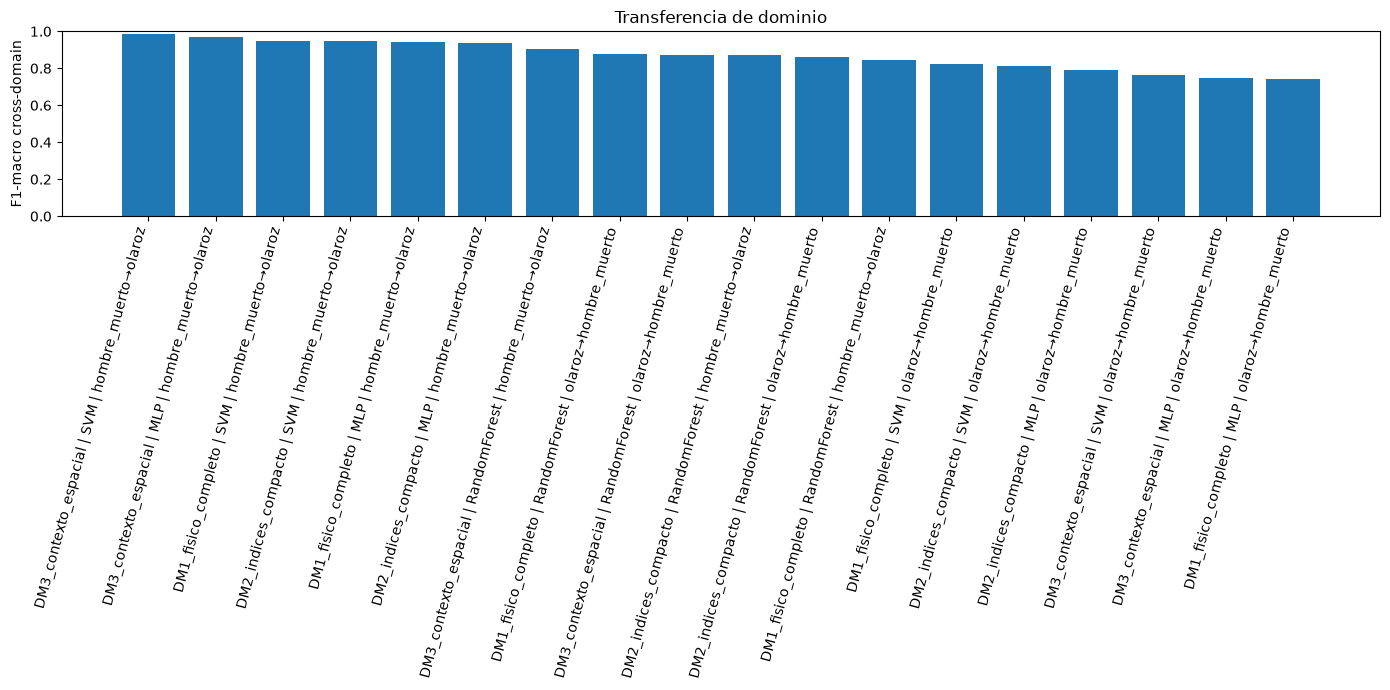

In [18]:
plot_transfer = transfer_results_df.copy()

plot_transfer["experiment"] = (
    plot_transfer["data_mart"]
    + " | "
    + plot_transfer["model"]
    + " | "
    + plot_transfer["source_domain"]
    + "→"
    + plot_transfer["target_domain"]
)

plot_transfer = plot_transfer.sort_values(
    "f1_macro",
    ascending=False,
)

plt.figure(figsize=(14, 7))
plt.bar(
    plot_transfer["experiment"],
    plot_transfer["f1_macro"],
)
plt.ylabel("F1-macro cross-domain")
plt.title("Transferencia de dominio")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 16. Matrices de confusión

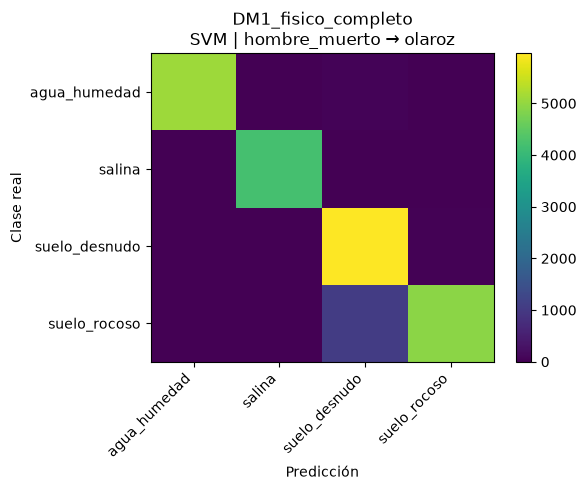

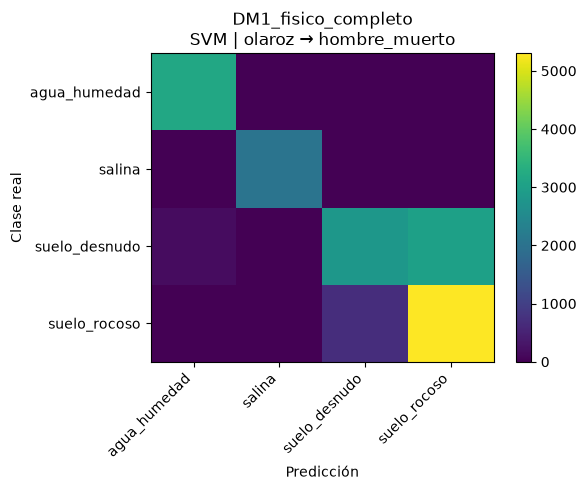

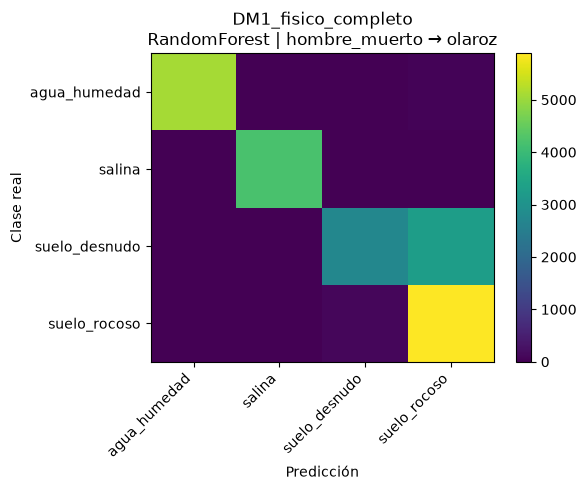

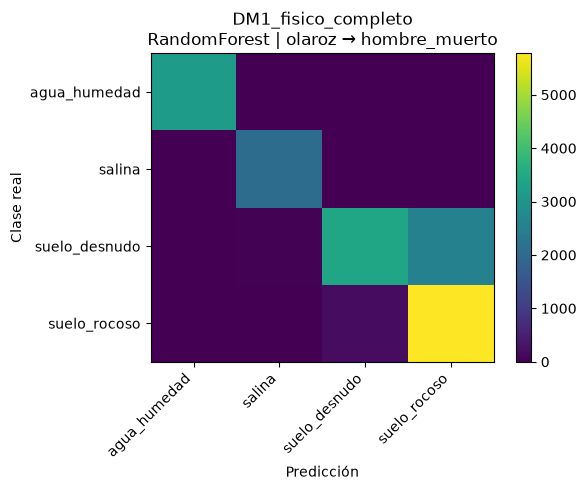

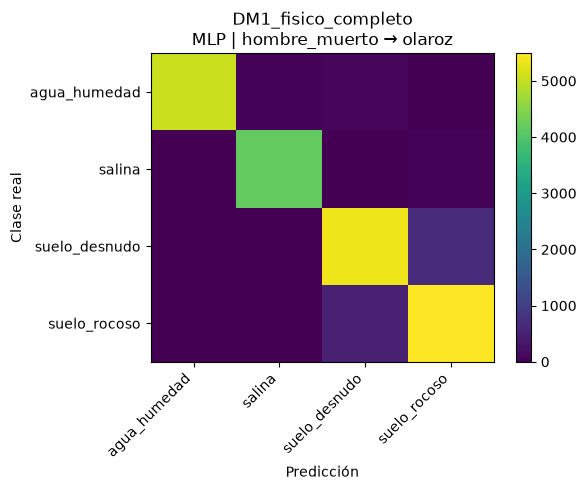

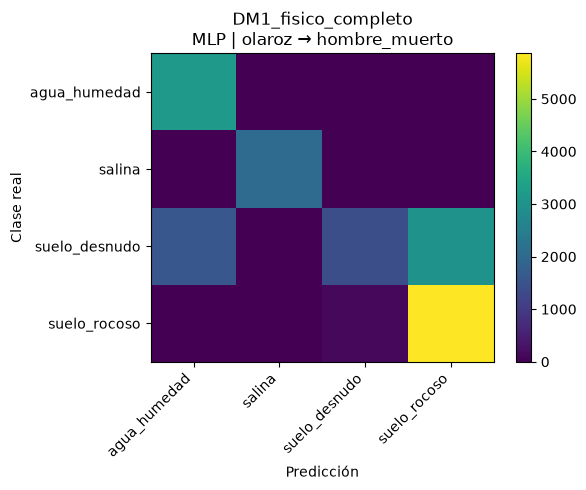

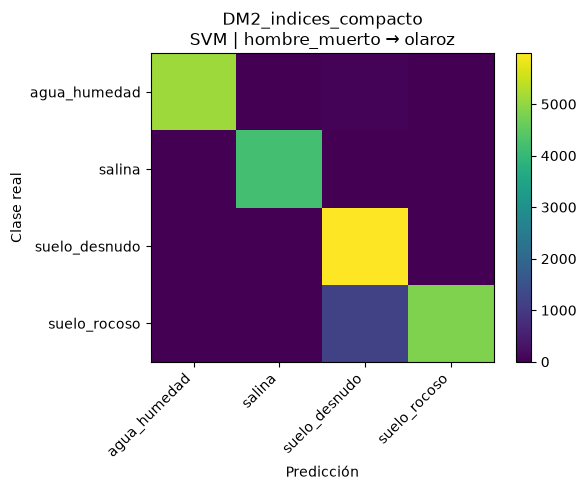

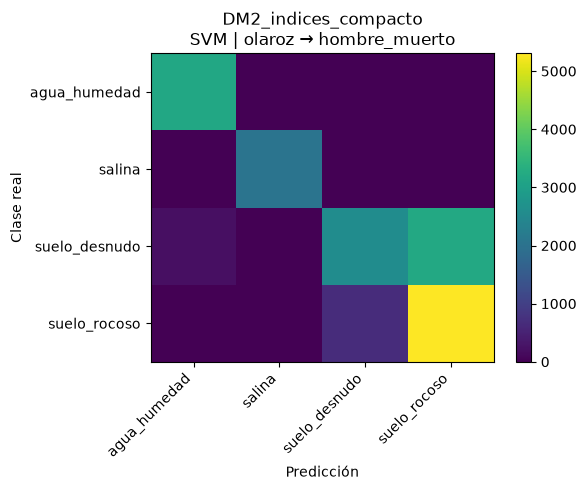

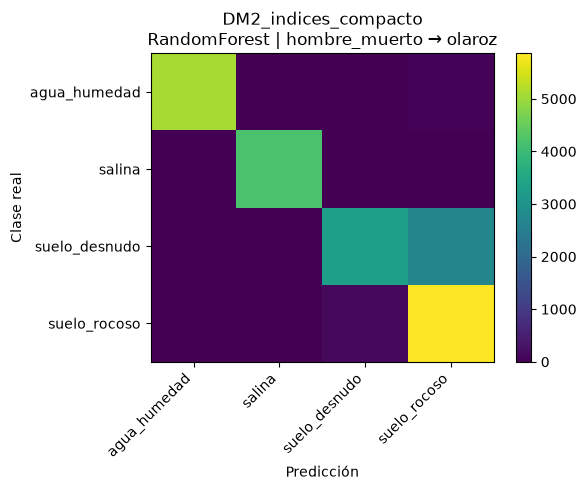

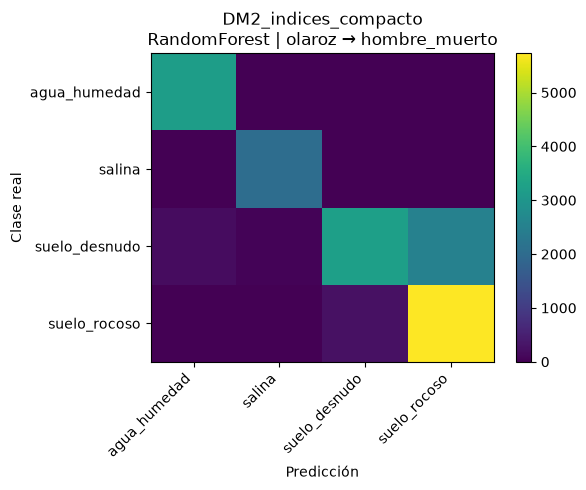

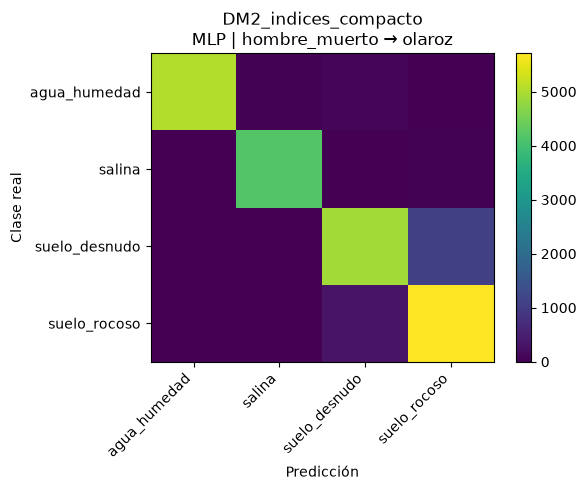

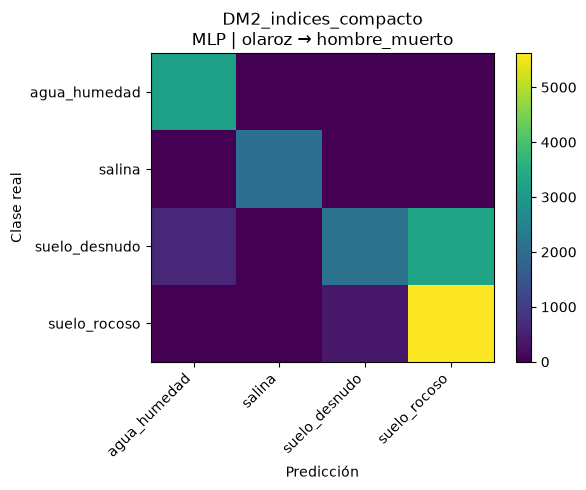

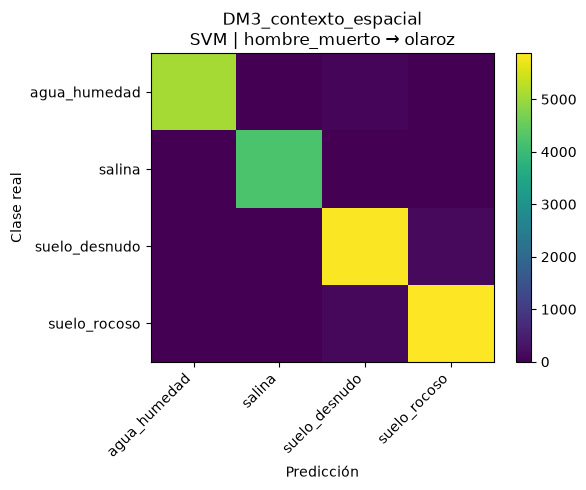

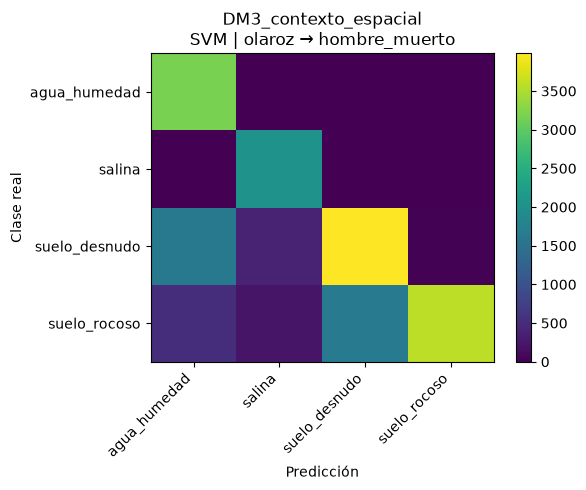

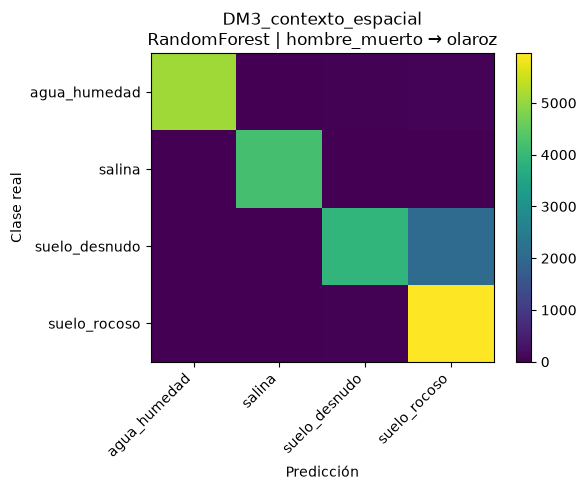

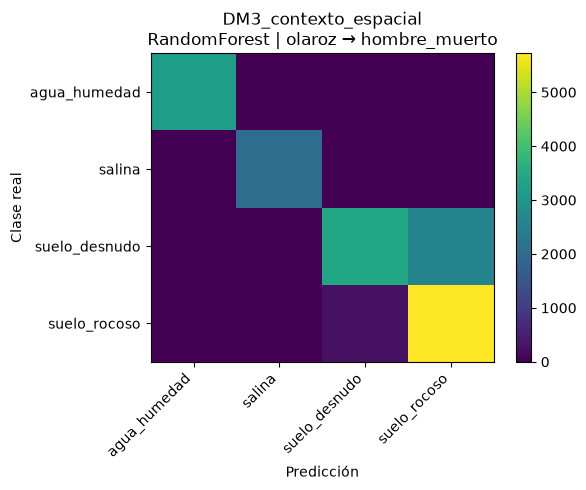

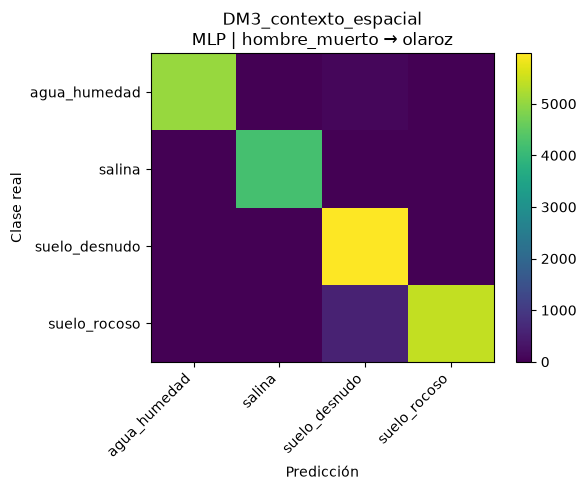

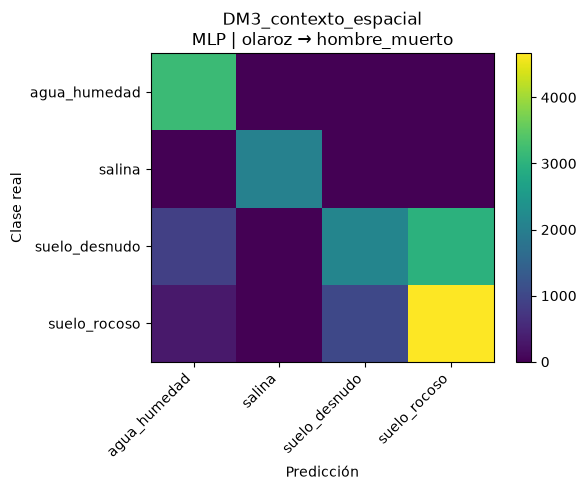

In [19]:
classes = sorted(
    data_mart_01[TARGET_COL].astype(str).unique()
)

for key, result in transfer_objects.items():
    mart_name, model_name, source_domain, target_domain = key
    cm = result["confusion_matrix"]

    plt.figure(figsize=(6, 5))
    image = plt.imshow(cm, aspect="auto")
    plt.colorbar(image)

    plt.xticks(
        range(len(classes)),
        classes,
        rotation=45,
        ha="right",
    )
    plt.yticks(range(len(classes)), classes)

    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.title(
        f"{mart_name}\n"
        f"{model_name} | {source_domain} → {target_domain}"
    )

    plt.tight_layout()
    plt.show()

# 17. Métricas por clase

In [20]:
classification_rows = []

for key, result in transfer_objects.items():
    mart_name, model_name, source_domain, target_domain = key
    report = result["classification_report"]

    for class_name in classes:
        metrics = report[class_name]

        classification_rows.append(
            {
                "data_mart": mart_name,
                "model": model_name,
                "source_domain": source_domain,
                "target_domain": target_domain,
                "class": class_name,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1-score"],
                "support": metrics["support"],
            }
        )

classification_by_class_df = pd.DataFrame(classification_rows)
display(classification_by_class_df)

,data_mart,model,source_domain,target_domain,class,precision,recall,f1,support
0,DM1_fisico_completo,SVM,hombre_muerto,olaroz,agua_humedad,1.000000,0.983762,0.991814,5173.0
1,DM1_fisico_completo,SVM,hombre_muerto,olaroz,salina,0.995035,0.998103,0.996567,4217.0
2,DM1_fisico_completo,SVM,hombre_muerto,olaroz,suelo_desnudo,0.840563,0.994667,0.911145,6000.0
3,DM1_fisico_completo,SVM,hombre_muerto,olaroz,suelo_rocoso,0.993563,0.823167,0.900374,6000.0
4,DM1_fisico_completo,SVM,olaroz,hombre_muerto,agua_humedad,0.942012,1.000000,0.970140,3184.0
5,DM1_fisico_completo,SVM,olaroz,hombre_muerto,salina,0.999512,1.000000,0.999756,2047.0
6,DM1_fisico_completo,SVM,olaroz,hombre_muerto,suelo_desnudo,0.803669,0.467333,0.591000,6000.0
7,DM1_fisico_completo,SVM,olaroz,hombre_muerto,suelo_rocoso,0.637599,0.883500,0.740673,6000.0
8,DM1_fisico_completo,RandomForest,hombre_muerto,olaroz,agua_humedad,1.000000,0.985888,0.992894,5173.0
9,DM1_fisico_completo,RandomForest,hombre_muerto,olaroz,salina,1.000000,0.996206,0.998099,4217.0


# 18. Importancia de variables — Random Forest

In [21]:
rf_importance_rows = []

for mart_name, spec in data_mart_specs.items():
    estimator = best_estimators[(mart_name, "RandomForest")]
    rf_model = estimator.named_steps["model"]
    features = spec["features"]

    for feature, importance in zip(
        features,
        rf_model.feature_importances_,
    ):
        rf_importance_rows.append(
            {
                "data_mart": mart_name,
                "feature": feature,
                "importance": float(importance),
            }
        )

rf_importance_df = pd.DataFrame(rf_importance_rows)

display(
    rf_importance_df.sort_values(
        ["data_mart", "importance"],
        ascending=[True, False],
    )
)

,data_mart,feature,importance
11,DM1_fisico_completo,feat_NDWI,0.100861
21,DM1_fisico_completo,eng_nir_red_ratio,0.081259
10,DM1_fisico_completo,feat_NDVI,0.075924
7,DM1_fisico_completo,spec_B8A,0.068547
26,DM1_fisico_completo,eng_visible_nir_contrast,0.060429
24,DM1_fisico_completo,eng_rededge_nir_ratio,0.056200
17,DM1_fisico_completo,eng_nir_mean,0.052952
5,DM1_fisico_completo,spec_B07,0.050754
6,DM1_fisico_completo,spec_B08,0.050080
2,DM1_fisico_completo,spec_B02,0.049258


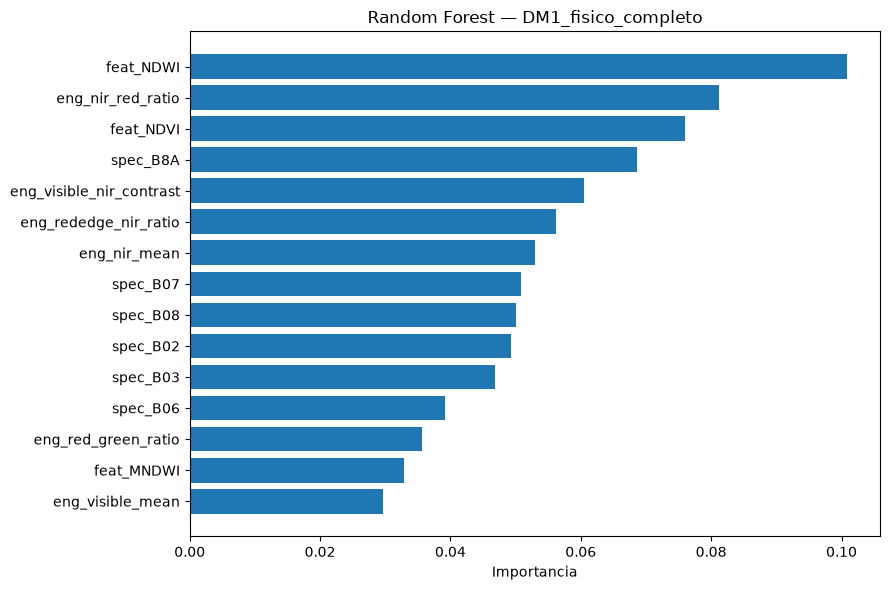

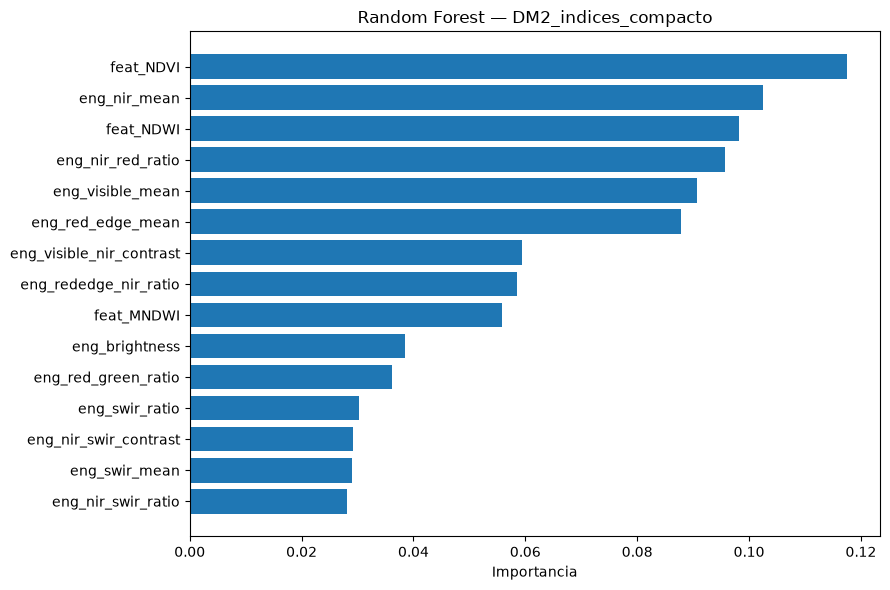

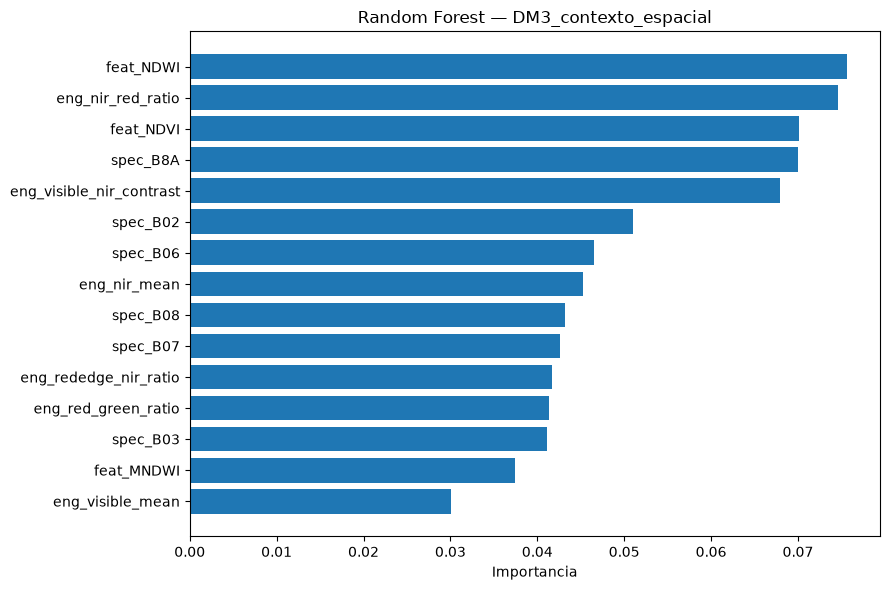

In [22]:
for mart_name in rf_importance_df["data_mart"].unique():
    top = (
        rf_importance_df[
            rf_importance_df["data_mart"] == mart_name
        ]
        .sort_values("importance", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(9, 6))
    plt.barh(
        top["feature"][::-1],
        top["importance"][::-1],
    )
    plt.xlabel("Importancia")
    plt.title(f"Random Forest — {mart_name}")
    plt.tight_layout()
    plt.show()

# 19. Permutation Importance para el mejor modelo de cada Data Mart

In [23]:
def permutation_importance_for_model(
    estimator,
    data: pd.DataFrame,
    feature_columns: list[str],
    sample_size: int,
) -> pd.DataFrame:

    evaluation_df = data.sample(
        n=min(sample_size, len(data)),
        random_state=RANDOM_STATE,
    ).copy()

    X = evaluation_df[feature_columns]
    y = evaluation_df[TARGET_COL].astype(str)

    result = permutation_importance(
        estimator,
        X,
        y,
        scoring="f1_macro",
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )

    return (
        pd.DataFrame(
            {
                "feature": feature_columns,
                "importance_mean": result.importances_mean,
                "importance_std": result.importances_std,
            }
        )
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

In [24]:
best_global_per_mart = (
    global_results_df
    .sort_values("best_cv_f1_macro", ascending=False)
    .groupby("data_mart", as_index=False)
    .first()
)

permutation_reports = []

for _, row in best_global_per_mart.iterrows():
    mart_name = row["data_mart"]
    model_name = row["model"]

    estimator = best_estimators[(mart_name, model_name)]
    data = data_mart_specs[mart_name]["data"]
    features = data_mart_specs[mart_name]["features"]

    print(
        f"Permutation Importance: {mart_name} | {model_name}"
    )

    report = permutation_importance_for_model(
        estimator=estimator,
        data=data,
        feature_columns=features,
        sample_size=PERMUTATION_SAMPLE_SIZE,
    )

    report["data_mart"] = mart_name
    report["model"] = model_name
    permutation_reports.append(report)

permutation_importance_df = pd.concat(
    permutation_reports,
    ignore_index=True,
)

display(permutation_importance_df)

Permutation Importance: DM1_fisico_completo | SVM
Permutation Importance: DM2_indices_compacto | SVM
Permutation Importance: DM3_contexto_espacial | SVM


,feature,importance_mean,importance_std,data_mart,model
0,spec_B12,0.170907,0.004221,DM1_fisico_completo,SVM
1,feat_NDMI,0.170754,0.004842,DM1_fisico_completo,SVM
2,spec_B03,0.153824,0.005519,DM1_fisico_completo,SVM
3,feat_BSI,0.141160,0.002306,DM1_fisico_completo,SVM
4,spec_B02,0.140650,0.002185,DM1_fisico_completo,SVM
5,eng_rededge_nir_ratio,0.113570,0.004452,DM1_fisico_completo,SVM
6,eng_visible_mean,0.110029,0.002212,DM1_fisico_completo,SVM
7,eng_red_green_ratio,0.109285,0.003359,DM1_fisico_completo,SVM
8,feat_MNDWI,0.103369,0.006116,DM1_fisico_completo,SVM
9,eng_swir_mean,0.098806,0.004157,DM1_fisico_completo,SVM


# 20. Tabla maestra

In [25]:
transfer_summary = (
    transfer_results_df
    .groupby(["data_mart", "model"], as_index=False)
    .agg(
        transfer_f1_mean=("f1_macro", "mean"),
        transfer_f1_std=("f1_macro", "std"),
        transfer_balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        delta_f1_mean=("delta_f1_transfer", "mean"),
    )
)

master_comparison = (
    global_results_df[
        [
            "data_mart",
            "model",
            "best_cv_f1_macro",
            "fit_seconds",
            "best_params",
        ]
    ]
    .merge(
        transfer_summary,
        on=["data_mart", "model"],
        how="left",
    )
)

display(
    master_comparison.sort_values(
        ["transfer_f1_mean", "best_cv_f1_macro"],
        ascending=[False, False],
    )
)

,data_mart,model,best_cv_f1_macro,fit_seconds,best_params,transfer_f1_mean,transfer_f1_std,transfer_balanced_accuracy_mean,delta_f1_mean
7,DM3_contexto_espacial,RandomForest,0.915328,1316.317346,"{""model__max_depth"": 20, ""model__max_features""...",0.889248,0.022852,0.893696,-0.054658
0,DM1_fisico_completo,SVM,0.956856,131.098286,"{""model__C"": 1.0, ""model__gamma"": ""scale"", ""mo...",0.887684,0.088093,0.893816,0.050019
3,DM2_indices_compacto,SVM,0.955946,118.477767,"{""model__C"": 5.0, ""model__gamma"": ""scale"", ""mo...",0.879847,0.094523,0.887570,0.052735
6,DM3_contexto_espacial,SVM,0.925118,60.564572,"{""model__C"": 1.0, ""model__gamma"": ""scale"", ""mo...",0.873284,0.156233,0.899524,-0.030153
4,DM2_indices_compacto,RandomForest,0.917769,1151.298516,"{""model__max_depth"": 20, ""model__max_features""...",0.866584,0.008858,0.875568,0.042458
5,DM2_indices_compacto,MLP,0.929376,194.657175,"{""model__alpha"": 0.001, ""model__hidden_layer_s...",0.862698,0.103732,0.878544,0.050760
1,DM1_fisico_completo,RandomForest,0.922575,1359.239452,"{""model__max_depth"": 20, ""model__max_features""...",0.860074,0.021065,0.868637,0.045707
8,DM3_contexto_espacial,MLP,0.910524,103.304062,"{""model__alpha"": 0.001, ""model__hidden_layer_s...",0.858122,0.156843,0.875547,-0.024027
2,DM1_fisico_completo,MLP,0.931901,166.450456,"{""model__alpha"": 0.001, ""model__hidden_layer_s...",0.841768,0.143743,0.872871,0.070130


# 21. Interpretación

Una combinación puede rendir excelente en validación agrupada y transferir mal.

Patrón problemático:

```text
CV F1-macro            alto
Cross-domain F1-macro  bajo
Delta F1               grande
```

Patrón deseable:

```text
CV F1-macro            alto
Cross-domain F1-macro  alto
Delta F1               pequeño
```

La selección final debe considerar simultáneamente:

- rendimiento;
- transferencia;
- complejidad;
- estabilidad;
- interpretabilidad.

# 22. Exportar resultados

In [26]:
GLOBAL_RESULTS_PATH = OUTPUT_DIR / "benchmark_global_10fold.csv"
CV_DETAILS_PATH = OUTPUT_DIR / "gridsearch_cv_completo.csv"
TRANSFER_RESULTS_PATH = OUTPUT_DIR / "transferencia_dominio.csv"
CLASS_RESULTS_PATH = OUTPUT_DIR / "metricas_por_clase.csv"
RF_IMPORTANCE_PATH = OUTPUT_DIR / "rf_feature_importance.csv"
PERMUTATION_PATH = OUTPUT_DIR / "permutation_importance.csv"
MASTER_PATH = OUTPUT_DIR / "comparacion_maestra.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "predicciones_cross_domain.csv"
METADATA_OUT_PATH = OUTPUT_DIR / "metadata_experimento.json"


global_results_df.to_csv(
    GLOBAL_RESULTS_PATH,
    index=False,
)

pd.concat(
    cv_detail_frames,
    ignore_index=True,
).to_csv(
    CV_DETAILS_PATH,
    index=False,
)

transfer_results_df.to_csv(
    TRANSFER_RESULTS_PATH,
    index=False,
)

classification_by_class_df.to_csv(
    CLASS_RESULTS_PATH,
    index=False,
)

rf_importance_df.to_csv(
    RF_IMPORTANCE_PATH,
    index=False,
)

permutation_importance_df.to_csv(
    PERMUTATION_PATH,
    index=False,
)

master_comparison.to_csv(
    MASTER_PATH,
    index=False,
)

# 23. Exportar predicciones cross-domain

In [27]:
prediction_frames = []

for key, result in transfer_objects.items():
    mart_name, model_name, source_domain, target_domain = key

    pred_df = result["predictions"].copy()
    pred_df["data_mart"] = mart_name
    pred_df["model"] = model_name
    pred_df["target_domain"] = target_domain

    prediction_frames.append(pred_df)

all_predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True,
)

all_predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False,
)

# 24. Metadata reproducible

In [28]:
experiment_metadata = {
    "random_state": RANDOM_STATE,
    "global_cv": {
        "type": "StratifiedGroupKFold",
        "n_splits": GLOBAL_CV_FOLDS,
        "group": GROUP_COL,
        "target": TARGET_COL,
    },
    "transfer_cv": {
        "type": "StratifiedGroupKFold",
        "n_splits": TRANSFER_CV_FOLDS,
        "group": GROUP_COL,
    },
    "models": [
        "SVM",
        "RandomForest",
        "MLP",
    ],
    "primary_metric": "f1_macro",
    "low_ram_mode": LOW_RAM_MODE,
    "max_samples_per_polygon": (
        MAX_SAMPLES_PER_POLYGON
        if LOW_RAM_MODE
        else None
    ),
    "domain_transfer": [
        f"{DOMAIN_A} -> {DOMAIN_B}",
        f"{DOMAIN_B} -> {DOMAIN_A}",
    ],
    "rules": {
        "polygon_id_never_split": True,
        "salar_used_as_predictor": False,
        "target_domain_used_in_grid_search": False,
    },
}

with open(
    METADATA_OUT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_metadata,
        file,
        ensure_ascii=False,
        indent=4,
    )

# 25. Salidas

El notebook genera:

```text
outputs_supervised/
├── benchmark_global_10fold.csv
├── gridsearch_cv_completo.csv
├── transferencia_dominio.csv
├── metricas_por_clase.csv
├── rf_feature_importance.csv
├── permutation_importance.csv
├── comparacion_maestra.csv
├── predicciones_cross_domain.csv
└── metadata_experimento.json
```

La tabla más importante para comparar modelos y Data Marts es:

```text
comparacion_maestra.csv
```

In [29]:
print("NOTEBOOK 03 FINALIZADO")
print("=" * 70)

print("\nBenchmark global:")
print(GLOBAL_RESULTS_PATH.resolve())

print("\nGridSearch completo:")
print(CV_DETAILS_PATH.resolve())

print("\nTransferencia:")
print(TRANSFER_RESULTS_PATH.resolve())

print("\nMétricas por clase:")
print(CLASS_RESULTS_PATH.resolve())

print("\nRF importance:")
print(RF_IMPORTANCE_PATH.resolve())

print("\nPermutation importance:")
print(PERMUTATION_PATH.resolve())

print("\nComparación maestra:")
print(MASTER_PATH.resolve())

print("\nPredicciones:")
print(PREDICTIONS_PATH.resolve())

print("\nMetadata:")
print(METADATA_OUT_PATH.resolve())

NOTEBOOK 03 FINALIZADO

Benchmark global:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_supervised\benchmark_global_10fold.csv

GridSearch completo:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_supervised\gridsearch_cv_completo.csv

Transferencia:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_supervised\transferencia_dominio.csv

Métricas por clase:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_supervised\metricas_por_clase.csv

RF importance:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_supervised\rf_feature_importance.csv

Permutation importance:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\me